In [1]:
import pandas as pd
import numpy as np

file_path = "../data/raw/yellow_tripdata_2026-01.parquet"

df = pd.read_parquet(file_path)
pd.set_option('display.max_columns',35)
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [2]:
df.shape

(3724889, 20)

# Data Cleaning

In [3]:
df.isna().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64

In [4]:
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

In [5]:
missing_cols = ((df['passenger_count'].isna()) & (df['RatecodeID'].isna()) & (df['store_and_fwd_flag'].isna()) &
               (df['congestion_surcharge'].isna()) &(df['Airport_fee'].isna()))
df.loc[missing_cols].shape

(1088058, 21)

**Missing Columns — Why We Don't Delete All**
```
Around 30% of the rows have missing values in some columns, but the rows still contain useful information like trip distance, fare, pickup/drop-off time, and trip duration.

So deleting all of them would throw away a large amount of useful data. Instead, we'll keep these rows for now and handle the missing columns separately when needed.

Missing values don't always mean the whole row is useless. We only remove a row when the missing/invalid data affects the analysis we're doing.

In [6]:
clean_df = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0)
].copy()

In [7]:
print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

Original rows: 3724889
Cleaned rows: 3560862
Rows removed: 164027


### trip distance analysis

In [8]:
clean_df['trip_distance'].describe([0.025,0.05,0.075,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.925,0.95,0.975,0.99,1])

count    3.560862e+06
mean     6.705575e+00
std      6.636609e+02
min      1.000000e-02
2.5%     3.800000e-01
5%       5.000000e-01
7.5%     6.000000e-01
10%      6.800000e-01
20%      9.500000e-01
30%      1.210000e+00
40%      1.520000e+00
50%      1.900000e+00
60%      2.400000e+00
70%      3.200000e+00
80%      4.800000e+00
90%      8.700000e+00
92.5%    1.014000e+01
95%      1.268000e+01
97.5%    1.742000e+01
99%      1.960000e+01
100%     2.690975e+05
max      2.690975e+05
Name: trip_distance, dtype: float64

In [9]:
high_miles = clean_df[clean_df['trip_distance'] > 50 ]
high_miles.shape

(582, 21)

In [10]:
before = len(clean_df)
clean_df = clean_df[clean_df['trip_distance'] <=50 ]
after = len(clean_df)
print('Rows removed: ',before - after)

Rows removed:  582


**Trip Distance — Threshold Selection**
```
Threshold selected: 50 miles

The 99th percentile is ~20 miles, so trips above 50 miles are extremely rare.
Only 582 rows exceed 50 miles out of ~3.3M records (~0.018%).
Values above this threshold are not representative of typical NYC taxi trips.
Removing them has minimal impact on the dataset while reducing extreme long-distance values that could distort analysis.

Conclusion: trip_distance > 50 miles is treated as an extreme outlier and removed. 

### analysis on trip duration

In [11]:
clean_df['trip_duration'].describe([0.025,0.05,0.075,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.925,0.95,0.975,0.99,1])

count    3.560280e+06
mean     1.724473e+01
std      2.420813e+01
min     -1.170000e+01
2.5%     2.350000e+00
5%       3.566667e+00
7.5%     4.350000e+00
10%      5.000000e+00
20%      7.150000e+00
30%      9.133333e+00
40%      1.115000e+01
50%      1.336667e+01
60%      1.595000e+01
70%      1.916667e+01
80%      2.371667e+01
90%      3.231667e+01
92.5%    3.643333e+01
95%      4.288333e+01
97.5%    5.488333e+01
99%      7.165000e+01
100%     5.293333e+03
max      5.293333e+03
Name: trip_duration, dtype: float64

In [12]:
df['trip_duration'].median()

np.float64(13.366666666666667)

In [13]:
duration_filter = (clean_df['trip_duration'] >= 80)

In [14]:
clean_df.loc[duration_filter,'fare_amount'].describe([0.025,0.05,0.075,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.925,0.95,0.975,0.99,0.999,1])

count    23312.000000
mean        55.089182
std         32.470168
min          0.010000
2.5%        15.600000
5%          26.500000
7.5%        30.500000
10%         32.500000
20%         38.500000
30%         42.500000
40%         46.500000
50%         50.500000
60%         54.500000
70%         60.500000
80%         70.000000
90%         72.500000
92.5%       80.500000
95%         92.354000
97.5%      119.114750
99%        172.774500
99.9%      288.382300
100%      2555.200000
max       2555.200000
Name: fare_amount, dtype: float64

In [15]:
clean_df.loc[duration_filter,'fare_amount'].median()

np.float64(50.5)

In [16]:
clean_df.loc[duration_filter,['fare_amount','trip_distance','trip_duration']].sort_values(by = 'fare_amount',ascending = False)

,fare_amount,trip_distance,trip_duration
2127025,2555.20,48.65,3525.700000
2435631,800.30,13.92,1121.150000
2260818,618.30,13.58,858.083333
280570,496.50,5.27,350.116667
1374105,375.00,47.10,89.683333
...,...,...,...
3341173,1.50,1.73,95.650000
183541,0.01,13.10,92.083333
1865731,0.01,0.07,100.716667
1630302,0.01,5.10,373.566667


In [17]:
clean_df.loc[duration_filter,['fare_amount','trip_distance','trip_duration']].sort_values(by = 'fare_amount',ascending = True)

,fare_amount,trip_distance,trip_duration
1630302,0.01,5.10,373.566667
183541,0.01,13.10,92.083333
1865731,0.01,0.07,100.716667
42078,0.01,14.00,107.300000
3064271,1.50,16.40,87.116667
...,...,...,...
1374105,375.00,47.10,89.683333
280570,496.50,5.27,350.116667
2260818,618.30,13.58,858.083333
2435631,800.30,13.92,1121.150000


**have irregularties price  vs trip duration vs distance so to have better idea we better groupby Ratecode ID**

In [18]:
ratecode_analysis = (
    clean_df
    .groupby('RatecodeID')
    .agg(
        total_fare=('fare_amount', 'sum'),
        total_distance=('trip_distance', 'sum')
    )
)

ratecode_analysis['avg_fare_per_distance'] = (
    ratecode_analysis['total_fare'] /
    ratecode_analysis['total_distance']
)

ratecode_analysis

,total_fare,total_distance,avg_fare_per_distance
RatecodeID,,,
1.0,37248521.23,5915712.58,6.296540
2.0,5543854.47,1410720.67,3.929803
3.0,747480.21,132694.74,5.633081
4.0,784021.30,147127.20,5.328867
5.0,1475480.85,152566.69,9.671055
6.0,6.00,1.30,4.615385
99.0,3906688.75,993087.36,3.933882


In [19]:
clean_df['fare_per_distance'] = (
    clean_df['fare_amount'] / clean_df['trip_distance']
)

clean_df.groupby('RatecodeID')['fare_per_distance'].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
)

,count,mean,std,min,1%,5%,50%,95%,99%,max
RatecodeID,,,,,,,,,,
1.0,2338778.0,8.754282,10.012661,0.102339,3.842105,4.279965,7.692308,15.000000,24.200000,4665.000000
2.0,79196.0,47.046338,472.351812,1.503436,2.512563,3.287929,3.914989,4.552106,875.000000,7000.000000
3.0,10031.0,28.507534,183.398169,1.608392,4.164053,4.673949,5.597588,36.857143,575.000000,2650.000000
4.0,7617.0,5.398995,1.541286,1.666667,3.867997,4.134535,5.157261,7.109813,8.182561,94.212524
5.0,19812.0,543.833789,1739.355285,0.000711,3.086637,4.599995,9.394682,2914.666667,8700.000000,49000.000000
6.0,2.0,9.886364,10.767308,2.272727,2.425000,3.034091,9.886364,16.738636,17.347727,17.500000
99.0,110236.0,6.083282,25.483495,0.397849,2.037895,2.724868,4.166667,11.751689,27.500000,3599.000000


**As we can See there is extreme outliers so we better use the IQR method to remove the outliers**

In [20]:
Q1 = clean_df.groupby('RatecodeID')['fare_per_distance'].transform(
    lambda x: x.quantile(0.25)
)

Q3 = clean_df.groupby('RatecodeID')['fare_per_distance'].transform(
    lambda x: x.quantile(0.75)
)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [21]:
outlier_filter = (
    (clean_df['fare_per_distance'] < lower_bound) |
    (clean_df['fare_per_distance'] > upper_bound)
)

print("Potential outliers:", outlier_filter.sum())
print("Percentage:", outlier_filter.mean() * 100)

Potential outliers: 135134
Percentage: 3.795600346040199


In [22]:
before = len(clean_df)

clean_df = clean_df.loc[~outlier_filter].copy()

after = len(clean_df)

print("Rows removed:", before - after)
print("Percentage removed:", (before - after) / before * 100)

Rows removed: 135134
Percentage removed: 3.795600346040199


**Fare per Distance — Outlier Removal**
```
Fare per distance was calculated as fare_amount / trip_distance.

The distribution showed extreme values, especially for some RatecodeIDs. Since these extreme values can distort the comparison of fare efficiency across rate codes, the IQR method (1.5 × IQR) was used to identify and remove outliers.

Result: 135,156 rows (~3.80%) were removed.

This leaves a more reliable dataset for comparing average fare per distance across RatecodeIDs.

**duration per distance analysis**

In [23]:
print('Negative_duration: ',len(clean_df.loc[clean_df['trip_duration'] < 0]))
print('Zero_duration: ',len(clean_df.loc[clean_df['trip_duration'] == 0]))

Negative_duration:  1
Zero_duration:  42131


In [24]:
clean_df['payment_type'] = clean_df['payment_type'].astype('category')

In [25]:
zero_duration = clean_df[clean_df['trip_duration'] == 0]

zero_duration.groupby('RatecodeID')['trip_distance'].describe(
    percentiles=[0.01, 0.05,0.25,0.50, 0.95, 0.99])

,count,mean,std,min,1%,5%,25%,50%,95%,99%,max
RatecodeID,,,,,,,,,,,
1.0,40938.0,2.231448,2.428716,0.25,0.3800,0.5400,0.950,1.50,7.3315,11.9700,48.40
2.0,648.0,17.906883,1.414600,14.88,15.4976,16.0500,16.920,17.64,20.5295,21.8819,22.73
3.0,65.0,15.247385,5.004972,0.99,1.0732,4.6500,13.420,16.78,19.6300,25.1860,32.29
4.0,98.0,16.719490,8.455725,3.14,5.6329,7.3225,9.940,15.07,32.5255,36.0055,47.50
5.0,371.0,10.633693,7.985847,0.01,0.0510,0.7300,5.555,9.07,26.0300,40.4490,46.36


**as we can see even for zero duration there are values like 0.25 14.88 .99 as mininum values and mean is pretty much high so we cannot
use this for analysis purpose so we better reomove them**

In [26]:
clean_df = clean_df[clean_df['trip_duration'] > 0]

In [27]:
duration_analysis = (
    clean_df
    .groupby('RatecodeID')
    .agg(
        total_duration = ('trip_duration','sum'),
        total_distance = ('trip_distance','sum')
    )
)

duration_analysis['duration_per_distance'] = (
    duration_analysis['total_duration'] /
    duration_analysis['total_distance']
)

duration_analysis

,total_duration,total_distance,duration_per_distance
RatecodeID,,,
1.0,3.129390e+07,5755068.31,5.437625
2.0,3.560418e+06,1331050.30,2.674894
3.0,3.230120e+05,129686.82,2.490708
4.0,2.907868e+05,144662.35,2.010107
5.0,4.294303e+05,148180.20,2.898027
6.0,6.050000e+00,1.30,4.653846
99.0,5.633579e+06,976525.58,5.769003


In [28]:
clean_df['duration_per_distance'] = (
    clean_df['trip_duration'] / clean_df['trip_distance']
)

clean_df.groupby('RatecodeID')['duration_per_distance'].describe(
    percentiles=[0.01, 0.05,0.25,0.50, 0.95, 0.99]
)

,count,mean,std,min,1%,5%,25%,50%,95%,99%,max
RatecodeID,,,,,,,,,,,
1.0,2183952.0,7.197886,17.325559,0.001621,1.788029,2.665718,5.005650,6.633333,12.600000,15.735460,5099.285714
2.0,73339.0,2.684740,1.395901,0.004167,1.460863,1.640251,2.042295,2.510204,4.207177,5.242276,139.400515
3.0,8684.0,2.653745,3.390564,0.066210,1.326112,1.506140,1.875226,2.319097,4.541637,5.941422,275.706288
4.0,7406.0,2.204093,1.195748,1.015576,1.180890,1.317378,1.605120,1.994158,3.729839,4.959700,60.861671
5.0,15032.0,3.856494,12.697059,0.004845,1.111111,1.413030,2.101488,2.903910,8.541097,15.088413,1438.809524
6.0,2.0,5.784091,2.308811,4.151515,4.184167,4.314773,4.967803,5.784091,7.253409,7.384015,7.416667
99.0,100002.0,6.720467,7.168731,0.017341,2.145015,2.814815,4.313948,5.905349,12.099975,17.049356,361.524691


In [29]:
clean_df.groupby('RatecodeID')['duration_per_distance'].describe(
    percentiles=[0.01, 0.05,0.25,0.50, 0.95, 0.99]
)

,count,mean,std,min,1%,5%,25%,50%,95%,99%,max
RatecodeID,,,,,,,,,,,
1.0,2183952.0,7.197886,17.325559,0.001621,1.788029,2.665718,5.005650,6.633333,12.600000,15.735460,5099.285714
2.0,73339.0,2.684740,1.395901,0.004167,1.460863,1.640251,2.042295,2.510204,4.207177,5.242276,139.400515
3.0,8684.0,2.653745,3.390564,0.066210,1.326112,1.506140,1.875226,2.319097,4.541637,5.941422,275.706288
4.0,7406.0,2.204093,1.195748,1.015576,1.180890,1.317378,1.605120,1.994158,3.729839,4.959700,60.861671
5.0,15032.0,3.856494,12.697059,0.004845,1.111111,1.413030,2.101488,2.903910,8.541097,15.088413,1438.809524
6.0,2.0,5.784091,2.308811,4.151515,4.184167,4.314773,4.967803,5.784091,7.253409,7.384015,7.416667
99.0,100002.0,6.720467,7.168731,0.017341,2.145015,2.814815,4.313948,5.905349,12.099975,17.049356,361.524691


In [30]:
Q1 = clean_df.groupby('RatecodeID')['duration_per_distance'].transform(
    lambda x : x.quantile(0.25)
)

Q3 = clean_df.groupby('RatecodeID')['duration_per_distance'].transform(
    lambda x: x.quantile(0.75)
)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [31]:
outlier_filter = (
    (clean_df['duration_per_distance'] < lower_bound) |
    (clean_df['duration_per_distance'] > upper_bound)
)

print("Potential outliers:", outlier_filter.sum())
print("Percentage:", outlier_filter.mean() * 100)

Potential outliers: 64424
Percentage: 1.9043373748970593


**Handling Duration per Distance Outliers.**
````
After removing invalid trip durations, we calculated duration_per_distance for each RatecodeID. Using the IQR method, around 1.9% of records were identified as potential outliers. Since these extreme values can distort duration and distance analysis, we remove them from the analytical dataset.

In [32]:
before = len(clean_df)

clean_df = clean_df.loc[~outlier_filter].copy()

after = len(clean_df)

print("Rows removed:", before - after)
print("Percentage removed:", (before - after) / before * 100)

Rows removed: 64424
Percentage removed: 1.9043373748970593


In [33]:
clean_df.groupby('RatecodeID')[['fare_per_distance']].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

fare_per_distance                                            \
                       count       mean        std       min        1%   
RatecodeID                                                               
1.0                2125797.0   7.723404   2.330399  0.764706  3.830645   
2.0                  71770.0   3.875458   0.288977  3.052769  3.181818   
3.0                   8364.0   5.671783   0.935290  3.719745  4.206358   
4.0                   7131.0   5.283983   0.858931  2.858675  3.875962   
5.0                  13926.0  11.187450  12.159222  0.000711  2.702494   
6.0                      2.0   9.886364  10.767308  2.272727  2.425000   
99.0                 97003.0   4.353858   1.442223  0.397849  1.989069   

                                                                           \
                  5%       25%       50%        75%        95%        99%   
RatecodeID                                                                  
1.0         4.237123  6.025237  7.457143   9.186047  12.033898  14.090909   
2.0         3.355705  3.688093  3.904071   4.076878   4.310345   4.490058   
3.0         4.664046  4.978009  5.347102   6.284896   7.407600   8.641189   
4.0         4.133458  4.627015  5.109075   5.846577   6.893066   7.398027   
5.0         4.394436  5.764486  7.492848  10.602645  31.695713  73.529412   
6.0         3.034091  6.079545  9.886364  13.693182  16.738636  17.347727   
99.0        2.674419  3.373016  3.965517   5.000000   7.413793   8.671608   

                        
                   max  
RatecodeID              
1.0          15.116279  
2.0           4.736130  
3.0           9.581395  
4.0           7.920046  
5.0         105.306667  
6.0          17.500000  
99.0          9.250000

In [34]:
print("Original Rows:", len(df))
print("Clean Rows:", len(clean_df))
print("Overall Rows Removed:", len(df) - len(clean_df))
print("Overall Percentage Removed:", (len(df) - len(clean_df)) / len(df) * 100)

print("\nNegative duration:", (clean_df['trip_duration'] < 0).sum())
print("Zero duration:", (clean_df['trip_duration'] == 0).sum())
print("Negative distance:", (clean_df['trip_distance'] < 0).sum())
print("Zero distance:", (clean_df['trip_distance'] == 0).sum())

Original Rows: 3724889
Clean Rows: 3318590
Overall Rows Removed: 406299
Overall Percentage Removed: 10.907680738942824

Negative duration: 0
Zero duration: 0
Negative distance: 0
Zero distance: 0


**Final Data Quality Check**
```
After cleaning, the dataset contains 3,319,131 rows. No negative or zero trip duration and no negative or zero trip distance values remain. The data is now suitable for further exploratory analysis and pipeline development.

### passenger count analysis

In [35]:
clean_df.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          994597
trip_distance                 0
RatecodeID               994597
store_and_fwd_flag       994597
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     994597
Airport_fee              994597
cbd_congestion_fee            0
trip_duration                 0
fare_per_distance             0
duration_per_distance         0
dtype: int64

In [36]:
clean_df.groupby('RatecodeID',dropna = False)[['passenger_count']].apply(lambda x: x.isna().sum())

,passenger_count
RatecodeID,
1.0,0
2.0,0
3.0,0
4.0,0
5.0,0
6.0,0
99.0,0
NaN,994597


````
all the passenger_count missing is coming from where RatecodeID is also went missing
since we already cleaned the data so we can keep them for analysis

In [37]:
clean_df.groupby('RatecodeID')[['passenger_count']].describe()

passenger_count                                             
                     count      mean       std  min  25%  50%  75%  max
RatecodeID                                                             
1.0              2125797.0  1.252445  0.667567  0.0  1.0  1.0  1.0  6.0
2.0                71770.0  1.479365  0.778585  0.0  1.0  1.0  2.0  6.0
3.0                 8364.0  1.540053  0.869974  0.0  1.0  1.0  2.0  6.0
4.0                 7131.0  1.393633  0.815873  0.0  1.0  1.0  1.0  6.0
5.0                13926.0  1.775241  1.123489  0.0  1.0  1.0  2.0  8.0
6.0                    2.0  1.000000  0.000000  1.0  1.0  1.0  1.0  1.0
99.0               97003.0  1.000000  0.000000  1.0  1.0  1.0  1.0  1.0

In [38]:
zero_passenger_count = clean_df[clean_df['passenger_count'] == 0]

zero_passenger_count.groupby('RatecodeID')['fare_per_distance'].describe(
    [0.05,0.1,0.25,0.30,0.50,0.70,0.85,0.90,0.95,0.99])


,count,mean,std,min,5%,10%,25%,30%,50%,70%,85%,90%,95%,99%,max
RatecodeID,,,,,,,,,,,,,,,
1.0,12628.0,7.996973,2.321840,0.882353,4.594203,5.192308,6.321429,6.615385,7.695652,9.000000,10.434472,11.285714,12.285714,14.500000,15.000000
2.0,141.0,3.829093,0.309094,3.070175,3.301887,3.398058,3.608247,3.703704,3.867403,4.022989,4.142012,4.191617,4.268293,4.447311,4.458599
3.0,35.0,5.288573,0.686459,4.248619,4.662971,4.838864,4.930567,4.951332,5.076923,5.378824,5.582444,6.153126,6.556237,7.462674,7.916667
4.0,15.0,5.148648,0.769279,3.983051,4.117415,4.210263,4.629123,4.780964,5.091324,5.679947,5.879779,5.943972,6.194514,6.585057,6.682692
5.0,54.0,11.071067,12.380368,0.001282,2.424706,4.023051,4.426326,4.650512,6.205128,10.389710,17.963016,27.023411,35.666667,55.183333,66.666667


In [39]:
zero_passenger_count.groupby('RatecodeID')['duration_per_distance'].describe()

,count,mean,std,min,25%,50%,75%,max
RatecodeID,,,,,,,,
1.0,12628.0,6.948815,2.504479,0.016667,5.196640,6.697096,8.467300,13.962963
2.0,141.0,2.739540,0.752864,1.430783,2.092179,2.680108,3.264815,4.535912
3.0,35.0,2.334447,0.680681,1.440891,1.858360,2.130631,2.723021,4.477273
4.0,15.0,1.936404,0.437883,1.252119,1.619197,1.967480,2.252862,2.801515
5.0,54.0,3.042511,1.682400,0.048048,2.130834,2.711284,3.625317,6.880952


In [40]:
clean_df.groupby(['RatecodeID','passenger_count'])['fare_per_distance'].describe()

count       mean        std        min  \
RatecodeID passenger_count                                               
1.0        0.0                12628.0   7.996973   2.321840   0.882353   
           1.0              1736918.0   7.725482   2.334524   0.764706   
           2.0               269172.0   7.701914   2.307657   1.153846   
           3.0                58247.0   7.746533   2.343839   1.139098   
           4.0                36098.0   7.706249   2.336349   0.770833   
           5.0                 8355.0   7.505650   2.113305   3.621922   
           6.0                 4379.0   7.680203   2.198344   3.632019   
2.0        0.0                  141.0   3.829093   0.309094   3.070175   
           1.0                45818.0   3.873151   0.289874   3.055434   
           2.0                20235.0   3.879311   0.287395   3.052769   
           3.0                 2999.0   3.888333   0.285903   3.075571   
           4.0                 2179.0   3.891095   0.285715   3.058104   
           5.0                  215.0   3.777142   0.294831   3.118040   
           6.0                  183.0   3.781250   0.253972   3.052769   
3.0        0.0                   35.0   5.288573   0.686459   4.248619   
           1.0                 5459.0   5.727146   0.947408   3.719745   
           2.0                 1558.0   5.643357   0.925383   4.043866   
           3.0                  973.0   5.524389   0.883870   4.038623   
           4.0                  316.0   5.393884   0.853941   4.087187   
           5.0                   15.0   5.189116   0.239935   4.722002   
           6.0                    8.0   4.914825   0.323848   4.170455   
4.0        0.0                   15.0   5.148648   0.769279   3.983051   
           1.0                 5372.0   5.285350   0.853891   3.440464   
           2.0                 1049.0   5.284522   0.870780   2.858675   
           3.0                  348.0   5.236186   0.871283   3.821363   
           4.0                  321.0   5.344508   0.907836   3.787044   
           5.0                   16.0   4.921331   0.689473   3.892264   
           6.0                   10.0   4.996279   0.432504   3.953356   
5.0        0.0                   54.0  11.071067  12.380368   0.001282   
           1.0                 8249.0  11.198102  12.759233   0.000711   
           2.0                 2653.0  11.400444  11.886460   0.042980   
           3.0                  733.0  11.508512  10.873273   1.645820   
           4.0                 2227.0  10.780422  10.437497   0.112360   
           5.0                    5.0   8.428423   3.745858   4.970760   
           6.0                    2.0   6.214527   0.315711   5.991285   
           7.0                    1.0  69.306931        NaN  69.306931   
           8.0                    2.0   6.226169   2.043628   4.781106   
6.0        1.0                    2.0   9.886364  10.767308   2.272727   
99.0       1.0                97003.0   4.353858   1.442223   0.397849   

                                  25%        50%        75%         max  
RatecodeID passenger_count                                               
1.0        0.0               6.321429   7.695652   9.431275   15.000000  
           1.0               6.020833   7.458564   9.189189   15.116279  
           2.0               6.029412   7.436975   9.139785   15.116279  
           3.0               6.047381   7.485380   9.230769   15.116279  
           4.0               6.000000   7.461812   9.186047   15.116279  
           5.0               6.000000   7.207207   8.707483   15.116279  
           6.0               6.149247   7.356322   8.952512   15.116279  
2.0        0.0               3.608247   3.867403   4.046243    4.458599  
           1.0               3.684211   3.897550   4.074505    4.736130  
           2.0               3.697834   3.912800   4.079254    4.736130  
           3.0               3.710575   3.932584   4.084014    4.723347  
           4.0               3.7174

````
from the above tabel we can see there is strong irregularties in RatecodeID 5 
so we gonna do further investigation on it
and delete if some serious outlier is present

In [41]:
rateid_5 = clean_df[clean_df['RatecodeID'] == 5]

rateid_5[['trip_distance','fare_amount','total_amount','fare_per_distance','duration_per_distance']].describe([0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99])

,trip_distance,fare_amount,total_amount,fare_per_distance,duration_per_distance
count,13926.000000,13926.000000,13926.000000,13926.000000,13926.000000
mean,10.494207,76.350819,96.438906,11.187450,3.087323
std,7.113181,35.257550,40.831037,12.159222,1.391169
min,0.030000,0.010000,1.010000,0.000711,0.004845
5%,1.400000,25.000000,32.250000,4.394436,1.400562
10%,2.415000,40.000000,49.250000,4.863388,1.577971
25%,5.660000,61.000000,79.850000,5.764486,2.041575
50%,9.015000,74.960000,95.210000,7.492848,2.777778
75%,15.050000,87.000000,109.122500,10.602645,3.828404
90%,18.030000,102.000000,130.225000,20.565184,5.155521


In [42]:
rateid_5[['trip_distance','fare_amount','total_amount','fare_per_distance','duration_per_distance','trip_duration']].sort_values(
    by = 'fare_amount', ascending = False
).head(10)

,trip_distance,fare_amount,total_amount,fare_per_distance,duration_per_distance,trip_duration
2035988,9.03,900.0,904.25,99.667774,2.755629,24.883333
1535785,8.35,650.0,651.00,77.844311,1.916168,16.000000
1542272,18.80,500.0,501.75,26.595745,3.778369,71.033333
3087,49.83,475.0,490.63,9.532410,1.564319,77.950000
1932848,21.20,460.0,461.00,21.698113,2.719340,57.650000
1374105,47.10,375.0,376.75,7.961783,1.904105,89.683333
1086369,6.18,375.0,475.99,60.679612,1.448220,8.950000
1145943,40.27,373.0,374.00,9.262478,2.525039,101.683333
1310626,49.43,350.0,430.15,7.080720,1.613055,79.733333
1230737,20.60,350.0,422.10,16.990291,2.888350,59.500000


In [43]:
rateid_5[['fare_per_distance','fare_amount','trip_distance']].sort_values(by = 'fare_per_distance').head(10)

,fare_per_distance,fare_amount,trip_distance
2042901,0.000711,0.01,14.06
2353976,0.000724,0.01,13.81
1823530,0.000734,0.01,13.63
1491520,0.000736,0.01,13.59
2557423,0.000744,0.01,13.44
183541,0.000763,0.01,13.10
905362,0.000764,0.01,13.09
1931082,0.000775,0.01,12.90
2129874,0.000818,0.01,12.22
14492,0.000843,0.01,11.86


In [44]:
rateid_5[['fare_per_distance','fare_amount','trip_distance']].sort_values(by = 'fare_per_distance').tail(10)

,fare_per_distance,fare_amount,trip_distance
1086533,103.614458,86.00,0.83
358965,103.703704,84.00,0.81
1564014,103.703704,84.00,0.81
17502,104.166667,125.00,1.20
1340292,104.615385,68.00,0.65
1567174,104.838710,65.00,0.62
511271,105.000000,63.00,0.60
106302,105.100000,94.59,0.90
1797163,105.100000,94.59,0.90
987425,105.306667,78.98,0.75


```
There are suspicious data on both left and right side so we are gonna investigate the both sides

In [45]:
rate5_suspicious = rateid_5[
    (rateid_5['fare_per_distance'] < 1) |
    (rateid_5['fare_per_distance'] > 50)
]

rate5_suspicious[
    [
        'trip_distance',
        'trip_duration',
        'fare_amount',
        'total_amount',
        'fare_per_distance',
        'duration_per_distance'
    ]
].sort_values('fare_per_distance')

,trip_distance,trip_duration,fare_amount,total_amount,fare_per_distance,duration_per_distance
2042901,14.06,34.333333,0.01,15.93,0.000711,2.441916
2353976,13.81,32.583333,0.01,15.93,0.000724,2.359401
1823530,13.63,30.483333,0.01,15.93,0.000734,2.236488
1491520,13.59,31.250000,0.01,15.93,0.000736,2.299485
2557423,13.44,33.966667,0.01,15.93,0.000744,2.527282
...,...,...,...,...,...,...
1567174,0.62,3.950000,65.00,81.00,104.838710,6.370968
511271,0.60,0.933333,63.00,64.00,105.000000,1.555556
1797163,0.90,0.250000,94.59,119.49,105.100000,0.277778
106302,0.90,3.583333,94.59,114.71,105.100000,3.981481


In [46]:
rate_5_left = rateid_5[
    (rateid_5['fare_per_distance'] < 1) &
    (rateid_5['trip_distance'] > 1)
]

rate_5_left[
    [
        'trip_distance',
        'trip_duration',
        'fare_amount',
        'total_amount',
        'fare_per_distance',
        'duration_per_distance'
    ]
].sort_values('trip_distance')

,trip_distance,trip_duration,fare_amount,total_amount,fare_per_distance,duration_per_distance
60625,1.54,1.866667,0.01,14.89,0.006494,1.212121
833240,1.68,2.683333,0.01,15.93,0.005952,1.597222
1093974,1.94,6.883333,0.01,15.93,0.005155,3.548110
10083,1.98,2.400000,0.01,14.89,0.005051,1.212121
135810,2.00,3.400000,0.01,14.89,0.005000,1.700000
...,...,...,...,...,...,...
2557423,13.44,33.966667,0.01,15.93,0.000744,2.527282
1491520,13.59,31.250000,0.01,15.93,0.000736,2.299485
1823530,13.63,30.483333,0.01,15.93,0.000734,2.236488
2353976,13.81,32.583333,0.01,15.93,0.000724,2.359401


````
   These values are not possible at all showing serious irregularities on our data so we better drop them before that 
   we also have to analyse the right side tail so that we can drop both together
   

In [47]:
clean_df.groupby(['RatecodeID'])['fare_per_distance'].describe([0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99])

,count,mean,std,min,5%,10%,25%,50%,75%,90%,95%,99%,max
RatecodeID,,,,,,,,,,,,,
1.0,2125797.0,7.723404,2.330399,0.764706,4.237123,4.775000,6.025237,7.457143,9.186047,10.975610,12.033898,14.090909,15.116279
2.0,71770.0,3.875458,0.288977,3.052769,3.355705,3.463632,3.688093,3.904071,4.076878,4.219409,4.310345,4.490058,4.736130
3.0,8364.0,5.671783,0.935290,3.719745,4.664046,4.787735,4.978009,5.347102,6.284896,6.956815,7.407600,8.641189,9.581395
4.0,7131.0,5.283983,0.858931,2.858675,4.133458,4.291953,4.627015,5.109075,5.846577,6.636132,6.893066,7.398027,7.920046
5.0,13926.0,11.187450,12.159222,0.000711,4.394436,4.863388,5.764486,7.492848,10.602645,20.565184,31.695713,73.529412,105.306667
6.0,2.0,9.886364,10.767308,2.272727,3.034091,3.795455,6.079545,9.886364,13.693182,15.977273,16.738636,17.347727,17.500000
99.0,97003.0,4.353858,1.442223,0.397849,2.674419,2.969619,3.373016,3.965517,5.000000,6.509434,7.413793,8.671608,9.250000


In [48]:
avg_distance = clean_df.groupby('RatecodeID')['trip_distance'].mean()
avg_distance

RatecodeID
1.0      2.670083
2.0     18.166550
3.0     15.086885
4.0     19.924943
5.0     10.494207
6.0      0.650000
99.0     9.928052
Name: trip_distance, dtype: float64

````
RateCodeID 5 shows substantially higher variability in fare_per_distance compared with other rate codes. The distribution contains extreme values that are inconsistent with the general fare-distance relationship. Instead of applying a generic IQR rule, a domain-informed threshold of 30 was selected to remove the clearly extreme right-tail observations while retaining the majority of legitimate RateCodeID 5 trips.

In [49]:
rate_5_right = rateid_5[
    (rateid_5['fare_per_distance'] > 30) 
]

rate_5_right[
    [
        'trip_distance',
        'trip_duration',
        'fare_amount',
        'total_amount',
        'fare_per_distance',
        'duration_per_distance'
    ]
].sort_values('fare_per_distance')

,trip_distance,trip_duration,fare_amount,total_amount,fare_per_distance,duration_per_distance
401248,2.84,6.233333,85.44,95.38,30.084507,2.194836
1246921,2.16,12.300000,65.00,79.20,30.092593,5.694444
730204,0.93,2.816667,28.00,32.25,30.107527,3.028674
528707,0.83,4.516667,25.00,35.10,30.120482,5.441767
350363,2.93,6.250000,88.44,89.44,30.184300,2.133106
...,...,...,...,...,...,...
1567174,0.62,3.950000,65.00,81.00,104.838710,6.370968
511271,0.60,0.933333,63.00,64.00,105.000000,1.555556
106302,0.90,3.583333,94.59,114.71,105.100000,3.981481
1797163,0.90,0.250000,94.59,119.49,105.100000,0.277778


In [50]:
clean_df = clean_df[
    ~(
        (clean_df['RatecodeID'] == 5) &
        (
            (clean_df['fare_per_distance'] < 1) |
            (clean_df['fare_per_distance'] > 30)
        )
    )
].copy()

In [51]:
print("Rows remaining:", len(clean_df))

clean_df[
    clean_df['RatecodeID'] == 5
]['fare_per_distance'].describe()

Rows remaining: 3317725


count    13061.000000
mean         8.822401
std          4.864678
min          1.053371
25%          5.703422
50%          7.319820
75%          9.789157
max         30.000000
Name: fare_per_distance, dtype: float64

In [52]:
clean_df.groupby(['RatecodeID'])['fare_per_distance'].describe([0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99])

,count,mean,std,min,5%,10%,25%,50%,75%,90%,95%,99%,max
RatecodeID,,,,,,,,,,,,,
1.0,2125797.0,7.723404,2.330399,0.764706,4.237123,4.775000,6.025237,7.457143,9.186047,10.975610,12.033898,14.090909,15.116279
2.0,71770.0,3.875458,0.288977,3.052769,3.355705,3.463632,3.688093,3.904071,4.076878,4.219409,4.310345,4.490058,4.736130
3.0,8364.0,5.671783,0.935290,3.719745,4.664046,4.787735,4.978009,5.347102,6.284896,6.956815,7.407600,8.641189,9.581395
4.0,7131.0,5.283983,0.858931,2.858675,4.133458,4.291953,4.627015,5.109075,5.846577,6.636132,6.893066,7.398027,7.920046
5.0,13061.0,8.822401,4.864678,1.053371,4.445635,4.869359,5.703422,7.319820,9.789157,15.384615,20.286396,27.152213,30.000000
6.0,2.0,9.886364,10.767308,2.272727,3.034091,3.795455,6.079545,9.886364,13.693182,15.977273,16.738636,17.347727,17.500000
99.0,97003.0,4.353858,1.442223,0.397849,2.674419,2.969619,3.373016,3.965517,5.000000,6.509434,7.413793,8.671608,9.250000


In [53]:
clean_df.loc[clean_df['RatecodeID'] == 1][['trip_distance','fare_amount','fare_per_distance']].sort_values('fare_per_distance').head(50)

,trip_distance,fare_amount,fare_per_distance
743485,8.50,6.5,0.764706
1487177,4.80,3.7,0.770833
259786,17.39,13.5,0.776308
2003126,17.10,13.5,0.789474
2016874,3.80,3.0,0.789474
1455134,3.80,3.0,0.789474
368552,3.70,3.0,0.810811
1833991,3.40,3.0,0.882353
838997,3.40,3.0,0.882353
2432946,3.30,3.0,0.909091


````

RatecodeID 1 is the standard taxi rate. Some trips have a low
fare_per_distance value (around 0.7), but that doesn't necessarily
mean the data is wrong.

The fare is not based only on the distance travelled. Other factors
like the base fare and time-based charges can also affect the total
fare.

Since these trips have reasonable distances and fare amounts, and
there is nothing clearly impossible about them, we decided to keep
these values instead of removing them as outliers.

In [54]:
clean_df['duration_per_distance'].describe([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

count    3.317725e+06
mean     1.645213e+01
std      1.508231e+02
min      1.621271e-03
1%       1.711560e+00
5%       2.371644e+00
10%      2.996344e+00
25%      4.474886e+00
50%      6.191919e+00
75%      8.129630e+00
90%      1.034050e+01
95%      1.188564e+01
99%      1.933333e+01
max      1.051000e+04
Name: duration_per_distance, dtype: float64

In [55]:
clean_df.groupby('RatecodeID',dropna = False)['duration_per_distance'].describe(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95,0.96,0.97,0.98,0.99]
)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,96%,97%,98%,99%,max
RatecodeID,,,,,,,,,,,,,,,,,
1.0,2125797.0,6.766039,2.607709,0.001621,1.779155,2.641026,3.461345,4.957537,6.546547,8.388889,10.381526,11.619048,11.955556,12.338308,12.785714,13.313492,13.971631
2.0,71770.0,2.607135,0.724499,1.154946,1.459373,1.637078,1.759918,2.033243,2.488813,3.076833,3.648153,4.001761,4.092484,4.198946,4.333525,4.515573,4.747414
3.0,8364.0,2.473612,0.787877,0.963542,1.321781,1.502614,1.614965,1.860715,2.282238,2.956443,3.655490,4.042774,4.152995,4.275919,4.429592,4.608413,4.866412
4.0,7131.0,2.084964,0.614836,1.015576,1.177474,1.311554,1.397384,1.590869,1.962310,2.465553,2.958376,3.313604,3.405740,3.509652,3.648274,3.762797,3.955823
5.0,13061.0,3.094895,1.355504,0.004845,1.141179,1.425104,1.609149,2.082742,2.795345,3.816964,5.077872,5.920543,6.111111,6.354195,6.607487,6.950331,7.385621
6.0,2.0,5.784091,2.308811,4.151515,4.184167,4.314773,4.478030,4.967803,5.784091,6.600379,7.090152,7.253409,7.286061,7.318712,7.351364,7.384015,7.416667
99.0,97003.0,6.180399,2.479652,0.017341,2.134695,2.797193,3.251844,4.269380,5.802288,7.757343,9.708333,10.905448,11.246357,11.650350,12.127907,12.742848,13.511111
NaN,994597.0,39.551505,274.046348,0.004433,1.866896,2.453017,2.957641,4.129512,5.730028,7.746599,10.641026,14.309711,16.472664,22.005281,189.229240,1450.000000,10510.000000


In [56]:
clean_df[
    ['RatecodeID', 'trip_distance', 'trip_duration',
     'duration_per_distance']
].sort_values('duration_per_distance').head(50)

,RatecodeID,trip_distance,trip_duration,duration_per_distance
2361940,1.0,10.28,0.016667,0.001621
1301259,1.0,19.70,0.066667,0.003384
3599701,NaN,3.76,0.016667,0.004433
175241,5.0,13.76,0.066667,0.004845
2284743,5.0,48.70,0.350000,0.007187
123729,5.0,8.70,0.066667,0.007663
2779012,NaN,2.15,0.016667,0.007752
2936473,NaN,2.14,0.016667,0.007788
2333179,1.0,17.87,0.150000,0.008394
1937660,1.0,15.30,0.133333,0.008715


In [57]:
clean_df[
    ['RatecodeID', 'trip_distance', 'trip_duration',
     'duration_per_distance']
].sort_values('duration_per_distance').tail(100)

,RatecodeID,trip_distance,trip_duration,duration_per_distance
3645202,NaN,0.01,59.083333,5908.333333
3594045,NaN,0.01,59.133333,5913.333333
3257593,NaN,0.01,59.450000,5945.000000
3353895,NaN,0.01,59.516667,5951.666667
3502990,NaN,0.01,59.633333,5963.333333
...,...,...,...,...
3064510,NaN,0.01,88.783333,8878.333333
3646703,NaN,0.01,93.450000,9345.000000
2980534,NaN,0.01,97.783333,9778.333333
3641053,NaN,0.01,99.950000,9995.000000


**Reason for cleaning duration_per_distance**
````
Observation: While checking duration_per_distance across different RateCodeIDs, most RateCodeIDs had maximum values around 4–14 minutes per mile. However, the records with missing RateCodeID had extremely high values, going up to 10,510 minutes per mile, mainly because of trips with extremely small distances.

On the lower side, we also found extremely small duration_per_distance values, which would imply unrealistically high travel speeds for a taxi trip.

Decision: We remove extremely low values below 0.8 and extremely high values above 14 to reduce the effect of these unrealistic observations.

In [58]:
before = len(clean_df)

clean_df = clean_df[
    clean_df['duration_per_distance'].between(0.8, 14)
].copy()

after = len(clean_df)

print('Number of Rows Removed: ', before - after)

Number of Rows Removed:  52441


In [59]:
print('Total percentage of data removed: ',(len(df)-len(clean_df))/len(df) * 100)

Total percentage of data removed:  12.338756940139692


In [60]:
(clean_df.isna().mean() * 100).sort_values()

VendorID                  0.000000
tpep_pickup_datetime      0.000000
tpep_dropoff_datetime     0.000000
trip_distance             0.000000
PULocationID              0.000000
fare_amount               0.000000
payment_type              0.000000
DOLocationID              0.000000
mta_tax                   0.000000
tip_amount                0.000000
tolls_amount              0.000000
extra                     0.000000
improvement_surcharge     0.000000
fare_per_distance         0.000000
cbd_congestion_fee        0.000000
total_amount              0.000000
duration_per_distance     0.000000
trip_duration             0.000000
store_and_fwd_flag       28.863339
passenger_count          28.863339
RatecodeID               28.863339
congestion_surcharge     28.863339
Airport_fee              28.863339
dtype: float64

In [61]:
clean_df.duplicated().sum()

np.int64(0)

In [62]:
clean_df.shape

(3265284, 23)

In [63]:
pd.set_option('display.max_columns',1000)
clean_df.groupby('RatecodeID',dropna = False)[
    ['passenger_count','trip_distance','fare_amount','trip_duration','fare_per_distance','duration_per_distance']].describe()

passenger_count                                               \
                     count      mean       std  min  25%  50%  75%  max   
RatecodeID                                                                
1.0              2125623.0  1.252464  0.667570  0.0  1.0  1.0  1.0  6.0   
2.0                71770.0  1.479365  0.778585  0.0  1.0  1.0  2.0  6.0   
3.0                 8364.0  1.540053  0.869974  0.0  1.0  1.0  2.0  6.0   
4.0                 7131.0  1.393633  0.815873  0.0  1.0  1.0  1.0  6.0   
5.0                12999.0  1.786753  1.127264  0.0  1.0  1.0  2.0  8.0   
6.0                    2.0  1.000000  0.000000  1.0  1.0  1.0  1.0  1.0   
99.0               96925.0  1.000000  0.000000  1.0  1.0  1.0  1.0  1.0   
NaN                    0.0       NaN       NaN  NaN  NaN  NaN  NaN  NaN   

           trip_distance                                                       \
                   count       mean        std    min     25%     50%     75%   
RatecodeID                                                                      
1.0            2125623.0   2.669964   3.088200   0.20   1.000   1.610   2.810   
2.0              71770.0  18.166550   1.403383  14.78  17.170  17.930  18.980   
3.0               8364.0  15.086885   5.845540   3.83   9.910  15.905  18.330   
4.0               7131.0  19.924943  10.151868   1.30  11.100  18.330  26.340   
5.0              12999.0  11.064520   6.962334   0.03   6.560   9.500  15.375   
6.0                  2.0   0.650000   0.636396   0.20   0.425   0.650   0.875   
99.0             96925.0   9.914646   5.253264   1.40   5.800   9.200  13.100   
NaN             942470.0   3.792798   3.169222   0.02   1.660   2.800   4.930   

                  fare_amount                                              \
              max       count        mean        std    min    25%    50%   
RatecodeID                                                                  
1.0         49.87   2125623.0   16.129289  12.245107   0.70   8.60  12.10   
2.0         22.93     71770.0   70.000184   0.049310  70.00  70.00  70.00   
3.0         48.70      8364.0   80.978708  21.485124  36.30  62.90  83.20   
4.0         49.85      7131.0  105.458856  56.977275  10.00  58.30  97.50   
5.0         49.85     12999.0   77.055736  33.639403   0.07  62.00  74.99   
6.0          1.10         2.0    3.000000   0.707107   2.50   2.75   3.00   
99.0        49.80     96925.0   37.122102  11.744847  11.50  27.50  35.50   
NaN         49.70    942470.0   25.113156  14.135686   0.42  15.31  22.19   

                           trip_duration                                   \
               75%     max         count       mean        std        min   
RatecodeID                                                                  
1.0          18.40  307.50     2125623.0  13.827840   9.673808   0.250000   
2.0          70.00   83.21       71770.0  47.220652  13.061474  18.850000   
3.0          93.70  209.90        8364.0  35.396688  13.743937   6.383333   
4.0         137.40  331.30        7131.0  38.642530  18.179684   1.433333   
5.0          87.00  500.00       12999.0  30.549960  17.669638   0.166667   
6.0           3.25    3.50           2.0   3.025000   2.180246   1.483333   
99.0         44.50  108.50       96925.0  54.555761  26.702397   4.383333   
NaN          31.20  618.68      942470.0  17.626316   9.626552   0.166667   

                                                        fare_per_distance  \
                  25%        50%        75%         max             count   
RatecodeID                                                                  
1.0          7.166667  11.350000  17.733333  395.250000         2125623.0   
2.0         37.083333  45.183333  55.666667  104.416667           71770.0   
3.0         26.129167  33.016667  42.333333  131.966667            8364.0   
4.0         24.541667  35.200000  49.233333  151.333333            7131.0   
5.0         18.033333  27.583333  39.875000  171.066667   

In [64]:
clean_df['passenger_count'].value_counts().sort_index()

passenger_count
0.0      12843
1.0    1897996
2.0     294503
3.0      63255
4.0      41028
5.0       8605
6.0       4582
8.0          2
Name: count, dtype: int64

In [65]:
clean_df['passenger_count'].isna().sum()

np.int64(942470)

In [66]:
nan_ratecode = clean_df[clean_df['RatecodeID'].isna()]

nan_ratecode.shape

(942470, 23)

In [67]:
nan_ratecode[
    ['trip_distance',
     'fare_amount',
     'trip_duration',
     'fare_per_distance',
     'duration_per_distance']
].describe([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95,0.96,0.97,0.98,0.99])

,trip_distance,fare_amount,trip_duration,fare_per_distance,duration_per_distance
count,942470.000000,942470.000000,942470.000000,942470.000000,942470.000000
mean,3.792798,25.113156,17.626316,9.445942,5.887442
std,3.169222,14.135686,9.626552,24.067133,2.477590
min,0.020000,0.420000,0.166667,0.056497,0.800469
1%,0.500000,6.330000,3.550000,2.786052,1.859871
5%,0.830000,9.100000,5.883333,3.521353,2.425429
10%,1.080000,11.180000,7.466667,4.071121,2.909961
25%,1.660000,15.310000,10.883333,5.427452,4.038981
50%,2.800000,22.190000,15.850000,7.552525,5.564103
75%,4.930000,31.200000,22.316667,10.449731,7.336172


In [68]:
nan_ratecode[
    ['trip_distance',
     'fare_amount',
     'trip_duration',
     'fare_per_distance',
     'duration_per_distance']
].sort_values(
    'fare_per_distance',
    ascending=False
).head(20)

,trip_distance,fare_amount,trip_duration,fare_per_distance,duration_per_distance
3577510,0.02,95.65,0.250000,4782.500000,12.500000
3130091,0.02,85.51,0.200000,4275.500000,10.000000
3439130,0.02,85.05,0.216667,4252.500000,10.833333
3487616,0.02,65.34,0.166667,3267.000000,8.333333
2812030,0.02,65.10,0.200000,3255.000000,10.000000
3510142,0.02,63.18,0.183333,3159.000000,9.166667
3027287,0.02,63.03,0.200000,3151.500000,10.000000
3621486,0.03,91.18,0.216667,3039.333333,7.222222
3490930,0.02,59.02,0.233333,2951.000000,11.666667
3447515,0.02,55.35,0.250000,2767.500000,12.500000


In [69]:
clean_df.groupby('RatecodeID',dropna = False)[
    ['fare_per_distance']].describe([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95,0.97,0.99])

fare_per_distance                                           \
                       count      mean        std       min        1%   
RatecodeID                                                              
1.0                2125623.0  7.723785   2.329987  0.789474  3.831522   
2.0                  71770.0  3.875458   0.288977  3.052769  3.181818   
3.0                   8364.0  5.671783   0.935290  3.719745  4.206358   
4.0                   7131.0  5.283983   0.858931  2.858675  3.875962   
5.0                  12999.0  8.807177   4.843811  1.166667  3.460568   
6.0                      2.0  9.886364  10.767308  2.272727  2.425000   
99.0                 96925.0  4.355951   1.439736  0.475664  2.015306   
NaN                 942470.0  9.445942  24.067133  0.056497  2.786052   

                                                                          \
                  5%       10%       25%       50%        75%        90%   
RatecodeID                                                                 
1.0         4.237979  4.775000  6.026667  7.457627   9.186047  10.975610   
2.0         3.355705  3.463632  3.688093  3.904071   4.076878   4.219409   
3.0         4.664046  4.787735  4.978009  5.347102   6.284896   6.956815   
4.0         4.133458  4.291953  4.627015  5.109075   5.846577   6.636132   
5.0         4.450051  4.873026  5.702174  7.313830   9.766204  15.321402   
6.0         3.034091  3.795455  6.079545  9.886364  13.693182  15.977273   
99.0        2.678571  2.972028  3.373984  3.965517   5.000000   6.514354   
NaN         3.521353  4.071121  5.427452  7.552525  10.449731  14.574766   

                                                          
                  95%        97%        99%          max  
RatecodeID                                                
1.0         12.033898  12.750000  14.090909    15.116279  
2.0          4.310345   4.366812   4.490058     4.736130  
3.0          7.407600   7.774714   8.641189     9.581395  
4.0          6.893066   7.044925   7.398027     7.920046  
5.0         20.204545  22.857143  27.084350    30.000000  
6.0         16.738636  17.043182  17.347727    17.500000  
99.0         7.413793   7.962963   8.673087     9.250000  
NaN         19.029165  23.303534  35.304955  4782.500000

In [70]:
before = len(clean_df)

clean_df = clean_df[
    (clean_df['passenger_count'] != 0) &
    (clean_df['fare_per_distance'].between(0.47, 30))
].copy()

after = len(clean_df)

print('Rows Removed:', before - after)
print('Percentage Removed:', (before - after) / before * 100)

Rows Removed: 29693
Percentage Removed: 0.9093542858752869


````
Observation: The missing RatecodeID group contains extreme values in fare_per_distance, ranging from 0.056 to 4782.5. In comparison, the maximum fare_per_distance among the known RatecodeID groups is 30.0, while the minimum observed value is approximately 0.47.

Decision: Since RatecodeID is missing for a substantial portion of the data, these rows were retained rather than removed entirely. Instead, fare_per_distance values outside the observed range of 0.47–30 were removed to reduce the influence of extreme observations.

Additionally, records with passenger_count = 0 were removed because they do not represent a valid passenger taxi trip.

In [71]:
clean_df.isna().sum().sort_values(ascending=False)

store_and_fwd_flag       925620
RatecodeID               925620
passenger_count          925620
Airport_fee              925620
congestion_surcharge     925620
tpep_dropoff_datetime         0
tpep_pickup_datetime          0
trip_distance                 0
VendorID                      0
PULocationID                  0
DOLocationID                  0
extra                         0
mta_tax                       0
payment_type                  0
fare_amount                   0
tolls_amount                  0
tip_amount                    0
total_amount                  0
improvement_surcharge         0
cbd_congestion_fee            0
trip_duration                 0
fare_per_distance             0
duration_per_distance         0
dtype: int64

In [72]:
clean_df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,3235591.0,1.805496,1.0,2.0,2.0,2.0,6.0,0.405698
tpep_pickup_datetime,3235591,2026-01-16 17:36:41.731856,2025-12-31 23:57:54,2026-01-09 14:42:16,2026-01-16 15:11:20,2026-01-23 19:19:00,2026-02-01 00:45:01,NaN
tpep_dropoff_datetime,3235591,2026-01-16 17:53:46.378922,2026-01-01 00:03:39,2026-01-09 15:00:27.500000,2026-01-16 15:32:17,2026-01-23 19:34:07.500000,2026-02-01 01:03:08,NaN
passenger_count,2309971.0,1.260367,1.0,1.0,1.0,1.0,8.0,0.662058
trip_distance,3235591.0,3.664088,0.03,1.19,2.03,4.15,49.87,4.250078
RatecodeID,2309971.0,5.181924,1.0,1.0,1.0,1.0,99.0,19.638042
PULocationID,3235591.0,161.204039,1.0,114.0,161.0,233.0,265.0,67.267464
DOLocationID,3235591.0,160.843979,1.0,107.0,161.0,234.0,265.0,71.499471
fare_amount,3235591.0,21.095775,0.07,10.0,15.6,26.1,500.0,16.991387
extra,3235591.0,1.093639,-0.75,0.0,0.0,2.5,17.46,1.723828


In [73]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 3235591 entries, 0 to 3724888
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           category      
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64       


In [74]:
clean_df.nunique()

VendorID                       3
tpep_pickup_datetime     1673486
tpep_dropoff_datetime    1672860
passenger_count                7
trip_distance               4190
RatecodeID                     7
store_and_fwd_flag             2
PULocationID                 261
DOLocationID                 260
payment_type                   5
fare_amount                11251
extra                         33
mta_tax                        4
tip_amount                  4102
tolls_amount                1181
improvement_surcharge          3
total_amount               17152
congestion_surcharge           2
Airport_fee                    2
cbd_congestion_fee             2
trip_duration               8641
fare_per_distance         517813
duration_per_distance     711535
dtype: int64

In [75]:
clean_df[['trip_distance',
          'fare_amount',
          'trip_duration',
          'fare_per_distance',
          'duration_per_distance']].describe()

,trip_distance,fare_amount,trip_duration,fare_per_distance,duration_per_distance
count,3.235591e+06,3.235591e+06,3.235591e+06,3.235591e+06,3.235591e+06
mean,3.664088e+00,2.109578e+01,1.707745e+01,7.743613e+00,6.356077e+00
std,4.250078e+00,1.699139e+01,1.363653e+01,3.176821e+00,2.641882e+00
min,3.000000e-02,7.000000e-02,1.666667e-01,4.702194e-01,8.004459e-01
25%,1.190000e+00,1.000000e+01,8.366667e+00,5.574534e+00,4.435841e+00
50%,2.030000e+00,1.560000e+01,1.346667e+01,7.266881e+00,6.129542e+00
75%,4.150000e+00,2.610000e+01,2.121667e+01,9.285714e+00,7.997512e+00
max,4.987000e+01,5.000000e+02,4.019333e+02,3.000000e+01,1.400000e+01


In [76]:
id_cols = [
    'VendorID',
    'RatecodeID',
    'PULocationID',
    'DOLocationID'
]

for col in id_cols:
    clean_df[col] = clean_df[col].astype('category')

In [77]:
clean_df['passenger_count'] = clean_df['passenger_count'].astype('Int8')

 # EDA

In [78]:
clean_df[
    [
        'passenger_count',
        'trip_distance',
        'fare_amount',
        'trip_duration',
        'tip_amount',
        'total_amount'
    ]
].describe([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95,0.97,0.99]).T

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,97%,99%,max
passenger_count,2309971.0,1.260367,0.662058,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0,3.0,4.0,8.0
trip_distance,3235591.0,3.664088,4.250078,0.03,0.41,0.6,0.77,1.19,2.03,4.15,9.02,13.16,17.03,19.6,49.87
fare_amount,3235591.0,21.095775,16.991387,0.07,5.1,6.5,7.2,10.0,15.6,26.1,41.99,57.5,70.0,77.2,500.0
trip_duration,3235591.0,17.077451,13.636528,0.166667,2.55,4.166667,5.4,8.366667,13.466667,21.216667,32.3,42.766667,51.433333,70.233333,401.933333
tip_amount,3235591.0,2.688656,3.823683,0.0,0.0,0.0,0.0,0.0,2.0,3.79,6.09,10.0,13.05,17.06,700.0
total_amount,3235591.0,29.730333,20.630838,0.0,10.08,12.6,13.94,17.22,23.1,33.94,53.72,75.29,89.7,104.03,725.1


In [79]:
clean_df[
    [
        'VendorID',
        'RatecodeID',
        'payment_type',
        'store_and_fwd_flag'
    ]
].nunique()

VendorID              3
RatecodeID            7
payment_type          5
store_and_fwd_flag    2
dtype: int64

##  Distribution of Trip Distance

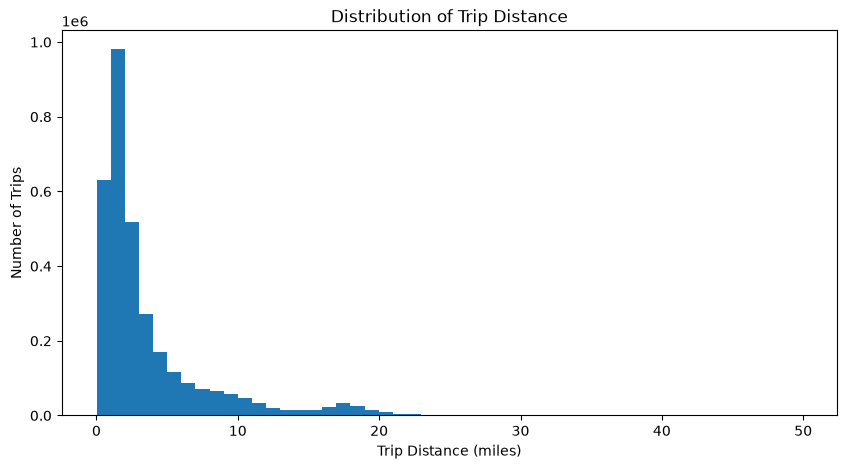

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(clean_df['trip_distance'], bins=50)

plt.xlabel('Trip Distance (miles)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Distance')

plt.show()

````
The trip distance distribution is strongly right-skewed. 
Most taxi trips are concentrated within a few miles, while a smaller 
number of trips have substantially longer distances, producing a long 
right tail. These longer trips may represent legitimate long-distance 
or airport trips and therefore should not be removed solely based on 
their distance.

## Distribution of Fare Amount

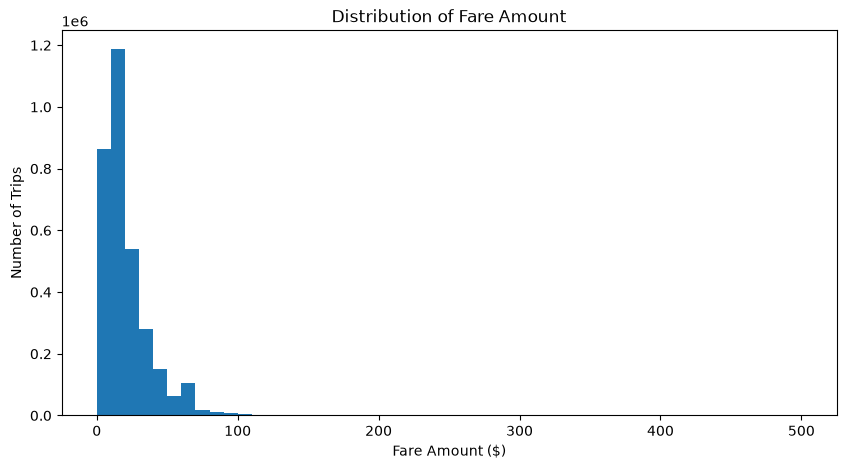

In [82]:
plt.figure(figsize = (10,5))

plt.hist(clean_df['fare_amount'], bins = 50)

plt.xlabel('Fare Amount ($)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Fare Amount')

plt.show()

````

The fare amount distribution is strongly right-skewed, with most trips
having relatively low fares and a long right tail. The median fare is
$15.60, while the 99th percentile is $77.20 and the maximum is $500.
This indicates the presence of extreme high-fare trips that require
further investigation rather than immediate removal.

##  Distribution of Trip Duration

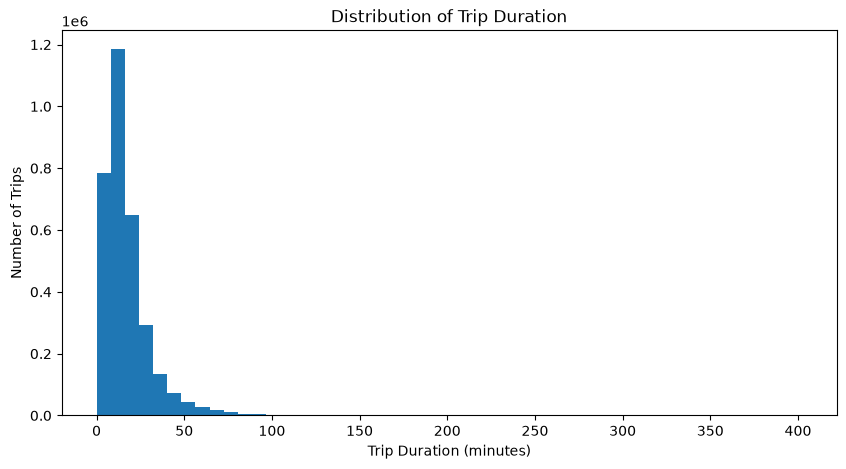

In [83]:
plt.figure(figsize=(10, 5))

plt.hist(clean_df['trip_duration'], bins=50)

plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Duration')

plt.show()

````
The trip duration distribution is strongly right-skewed. Most trips
are relatively short, with the majority concentrated below 30 minutes.
The 99th percentile is approximately 70 minutes, while the maximum
reaches approximately 402 minutes. This indicates the presence of
extreme long-duration trips that should be investigated before deciding
whether they represent valid trips or data anomalies.

## Distribution of Tip Amount

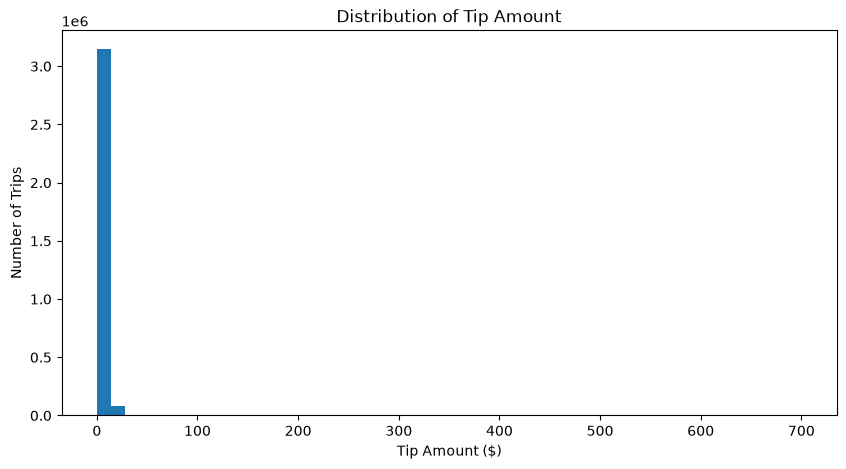

In [84]:
plt.figure(figsize=(10, 5))

plt.hist(clean_df['tip_amount'], bins=50)

plt.xlabel('Tip Amount ($)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Tip Amount')

plt.show()

In [85]:
clean_df[clean_df['tip_amount'] > 100][
    ['tip_amount', 'fare_amount', 'total_amount', 'payment_type', 'passenger_count', 'trip_distance']
].sort_values('tip_amount', ascending=False).head(20)

,tip_amount,fare_amount,total_amount,payment_type,passenger_count,trip_distance
911299,700.00,22.6,725.10,1,1,3.30
962774,630.45,5.8,642.75,1,2,0.70
1609187,472.98,12.1,489.83,1,6,1.76
2413139,445.45,7.9,460.60,1,1,0.90
291940,400.00,28.9,431.40,1,1,7.10
407839,355.00,18.4,378.15,1,6,2.34
332333,150.00,148.6,303.28,1,1,37.60
1956963,101.67,83.5,203.34,1,2,21.10
1584241,101.00,8.6,114.35,1,2,0.91


In [86]:
clean_df[['tip_amount']].describe(percentiles=[.90, .95, .99, .995, .999])

,tip_amount
count,3.235591e+06
mean,2.688656e+00
std,3.823683e+00
min,0.000000e+00
90%,6.090000e+00
95%,1.000000e+01
99%,1.706000e+01
99.5%,2.000000e+01
99.9%,2.735000e+01
max,7.000000e+02


In [87]:
clean_df['tip_percentage'] = (
    clean_df['tip_amount'] / clean_df['fare_amount']
) * 100

clean_df[
    clean_df['tip_percentage'] > 100
][
    ['tip_amount', 'fare_amount', 'tip_percentage',
     'total_amount', 'payment_type', 'trip_distance']
].sort_values(
    'tip_percentage',
    ascending=False
).head(20)

,tip_amount,fare_amount,tip_percentage,total_amount,payment_type,trip_distance
962774,630.45,5.80,10869.827586,642.75,1,0.70
892196,99.99,1.00,9999.000000,101.99,1,0.45
2413139,445.45,7.90,5638.607595,460.60,1,0.90
1609187,472.98,12.10,3908.925620,489.83,1,1.76
911299,700.00,22.60,3097.345133,725.10,1,3.30
407839,355.00,18.40,1929.347826,378.15,1,2.34
262,100.00,5.80,1724.137931,111.55,1,0.50
2555423,88.88,5.80,1532.413793,100.43,1,0.65
2051714,52.00,3.70,1405.405405,59.70,1,0.30
1762267,91.00,6.50,1400.000000,101.50,1,0.65


In [88]:
clean_df[
    clean_df['tip_percentage'] > 50
].shape

(36553, 24)

In [89]:
before = len(clean_df)

clean_df = clean_df[
    clean_df['tip_percentage'] <= 50
].copy()

after = len(clean_df)

print('Rows Removed:', before - after)
print('Percentage Removed:', (before - after) / before * 100)

Rows Removed: 36553
Percentage Removed: 1.1297163331212134


**Tip Amount Outliers**
```
* tip_amount was highly right-skewed.
* Maximum tip was $700, while 99.9% of tips were below $27.35.
* Created tip_percentage = (tip_amount / fare_amount) × 100.
* Found 36,553 rows where tip exceeded 50% of fare.
* Since >50% tip is highly unusual for taxi trips, these rows were treated as anomalies and removed.
* Removed approximately 1.13% of the dataset.

##  Distribution of Total Amount

In [90]:
clean_df['total_amount'].describe(
    percentiles=[.90, .95, .99, .995, .999]
)

count    3.199038e+06
mean     2.983723e+01
std      2.064304e+01
min      0.000000e+00
90%      5.394000e+01
95%      7.554000e+01
99%      1.040500e+02
99.5%    1.149300e+02
99.9%    1.650900e+02
max      5.017500e+02
Name: total_amount, dtype: float64

In [91]:
clean_df[clean_df['total_amount'] > 100].shape

(50780, 24)

In [92]:
clean_df[clean_df['total_amount'] > 100][
    ['total_amount', 'fare_amount', 'tip_amount',
     'trip_distance', 'trip_duration', 'payment_type']
].sort_values('total_amount', ascending=False).head(20)

,total_amount,fare_amount,tip_amount,trip_distance,trip_duration,payment_type
1542272,501.75,500.00,0.00,18.80,71.033333,1
3087,490.63,475.00,0.00,49.83,77.950000,1
1932848,461.00,460.00,0.00,21.20,57.650000,4
1310626,430.15,350.00,71.69,49.43,79.733333,1
367334,406.37,329.20,67.73,48.53,86.150000,1
1467217,405.31,331.30,67.26,49.46,59.900000,1
1639824,401.17,302.60,66.57,47.40,72.766667,1
2320492,397.07,284.40,91.63,40.37,80.716667,1
2306113,392.05,300.00,65.05,39.01,87.283333,1
1164388,391.73,305.40,65.29,43.63,69.033333,1


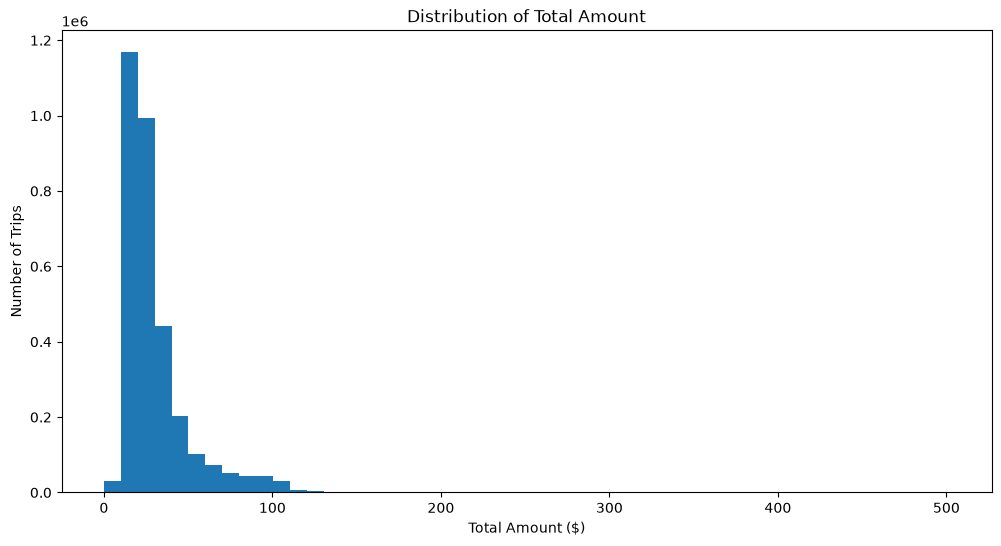

In [93]:
plt.figure(figsize=(12, 6))

plt.hist(clean_df['total_amount'], bins=50)

plt.title('Distribution of Total Amount')
plt.xlabel('Total Amount ($)')
plt.ylabel('Number of Trips')

plt.show()

**Distribution of Total Amount**
```
The values are mostly concentrated between $10 and $50 which looks reasonable for normal taxi trips.
There is a long right-side tail with some higher values, but they are supported by the fare amount, trip distance and trip duration.
So we won't drop these values just because they are high. We will analyse the extreme right-side values separately before deciding whether they are actual outliers.

## Fare Amount vs Trip Distance
```
We will check whether the fare amount generally increases with trip distance.
This can help us identify unusual trips where the fare and distance don't seem to match.

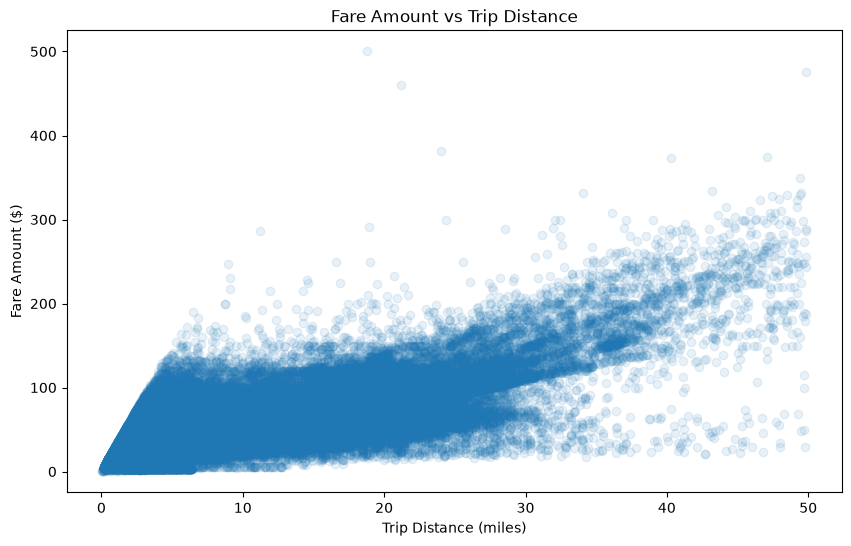

In [94]:
plt.figure(figsize=(10, 6))

plt.scatter(
    clean_df['trip_distance'],
    clean_df['fare_amount'],
    alpha=0.1
)

plt.title('Fare Amount vs Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')

plt.show()

```
Most trips follow a reasonable pattern where the fare amount increases with trip distance.
There are some high fare values in the dataset, but they are not associated with unusually short trips.
So we don't have enough evidence from this comparison to consider these values as invalid.

## Fare Amount vs Trip Duration
```
We will check whether the fare amount generally increases with trip duration.
This will help us identify trips where the fare and duration don't seem to match.

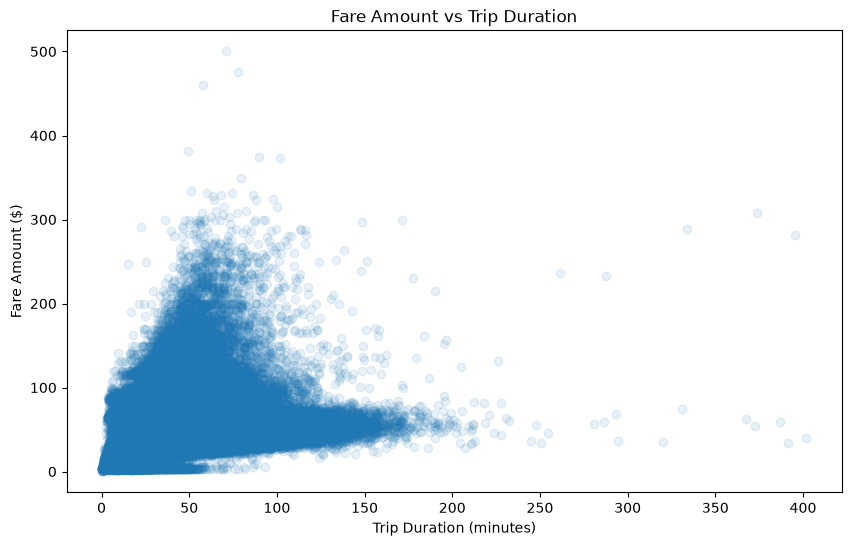

In [95]:
plt.figure(figsize=(10, 6))

plt.scatter(
    clean_df['trip_duration'],
    clean_df['fare_amount'],
    alpha=0.1
)

plt.title('Fare Amount vs Trip Duration')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')

plt.show()

````
Most of the trips show a reasonable relationship where fare amount generally increases with trip duration.
There are some extreme values with very high fares or very long durations, but these values are not enough to call them invalid.
We will keep them for now and only remove them if further analysis shows that they are clearly unrealistic.

## Trip Distance vs Trip Duration
```
We will check whether the trip distance and duration have a reasonable relationship.
This can help us identify trips with unusually long durations for very short distances or very long distances completed in an unusually short time.

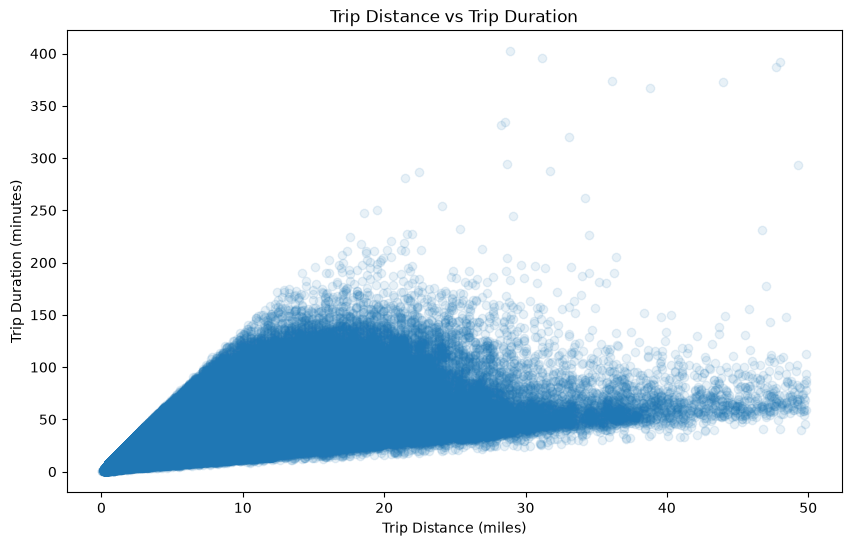

In [96]:
plt.figure(figsize=(10, 6))

plt.scatter(
    clean_df['trip_distance'],
    clean_df['trip_duration'],
    alpha=0.1
)

plt.title('Trip Distance vs Trip Duration')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Trip Duration (minutes)')

plt.show()

**Trip Distance vs Trip Duration**

Here we can see a **general positive relationship** between trip distance and trip duration — as the distance increases, the duration generally increases too.

Most of the data is concentrated in a reasonable range, but there are some **extreme duration values** (200–400+ minutes) for certain trips. These look unusual and should be checked as possible outliers.

For now, we can **keep the normal-looking data** and investigate those extreme values separately rather than blindly dropping them.


## Fare Amount vs Trip Distance by Rate Code

Different RatecodeIDs may follow different pricing rules, so comparing all trips together may hide these patterns.

We use separate subplots for each RatecodeID to understand how fare amount changes with trip distance within each rate category.

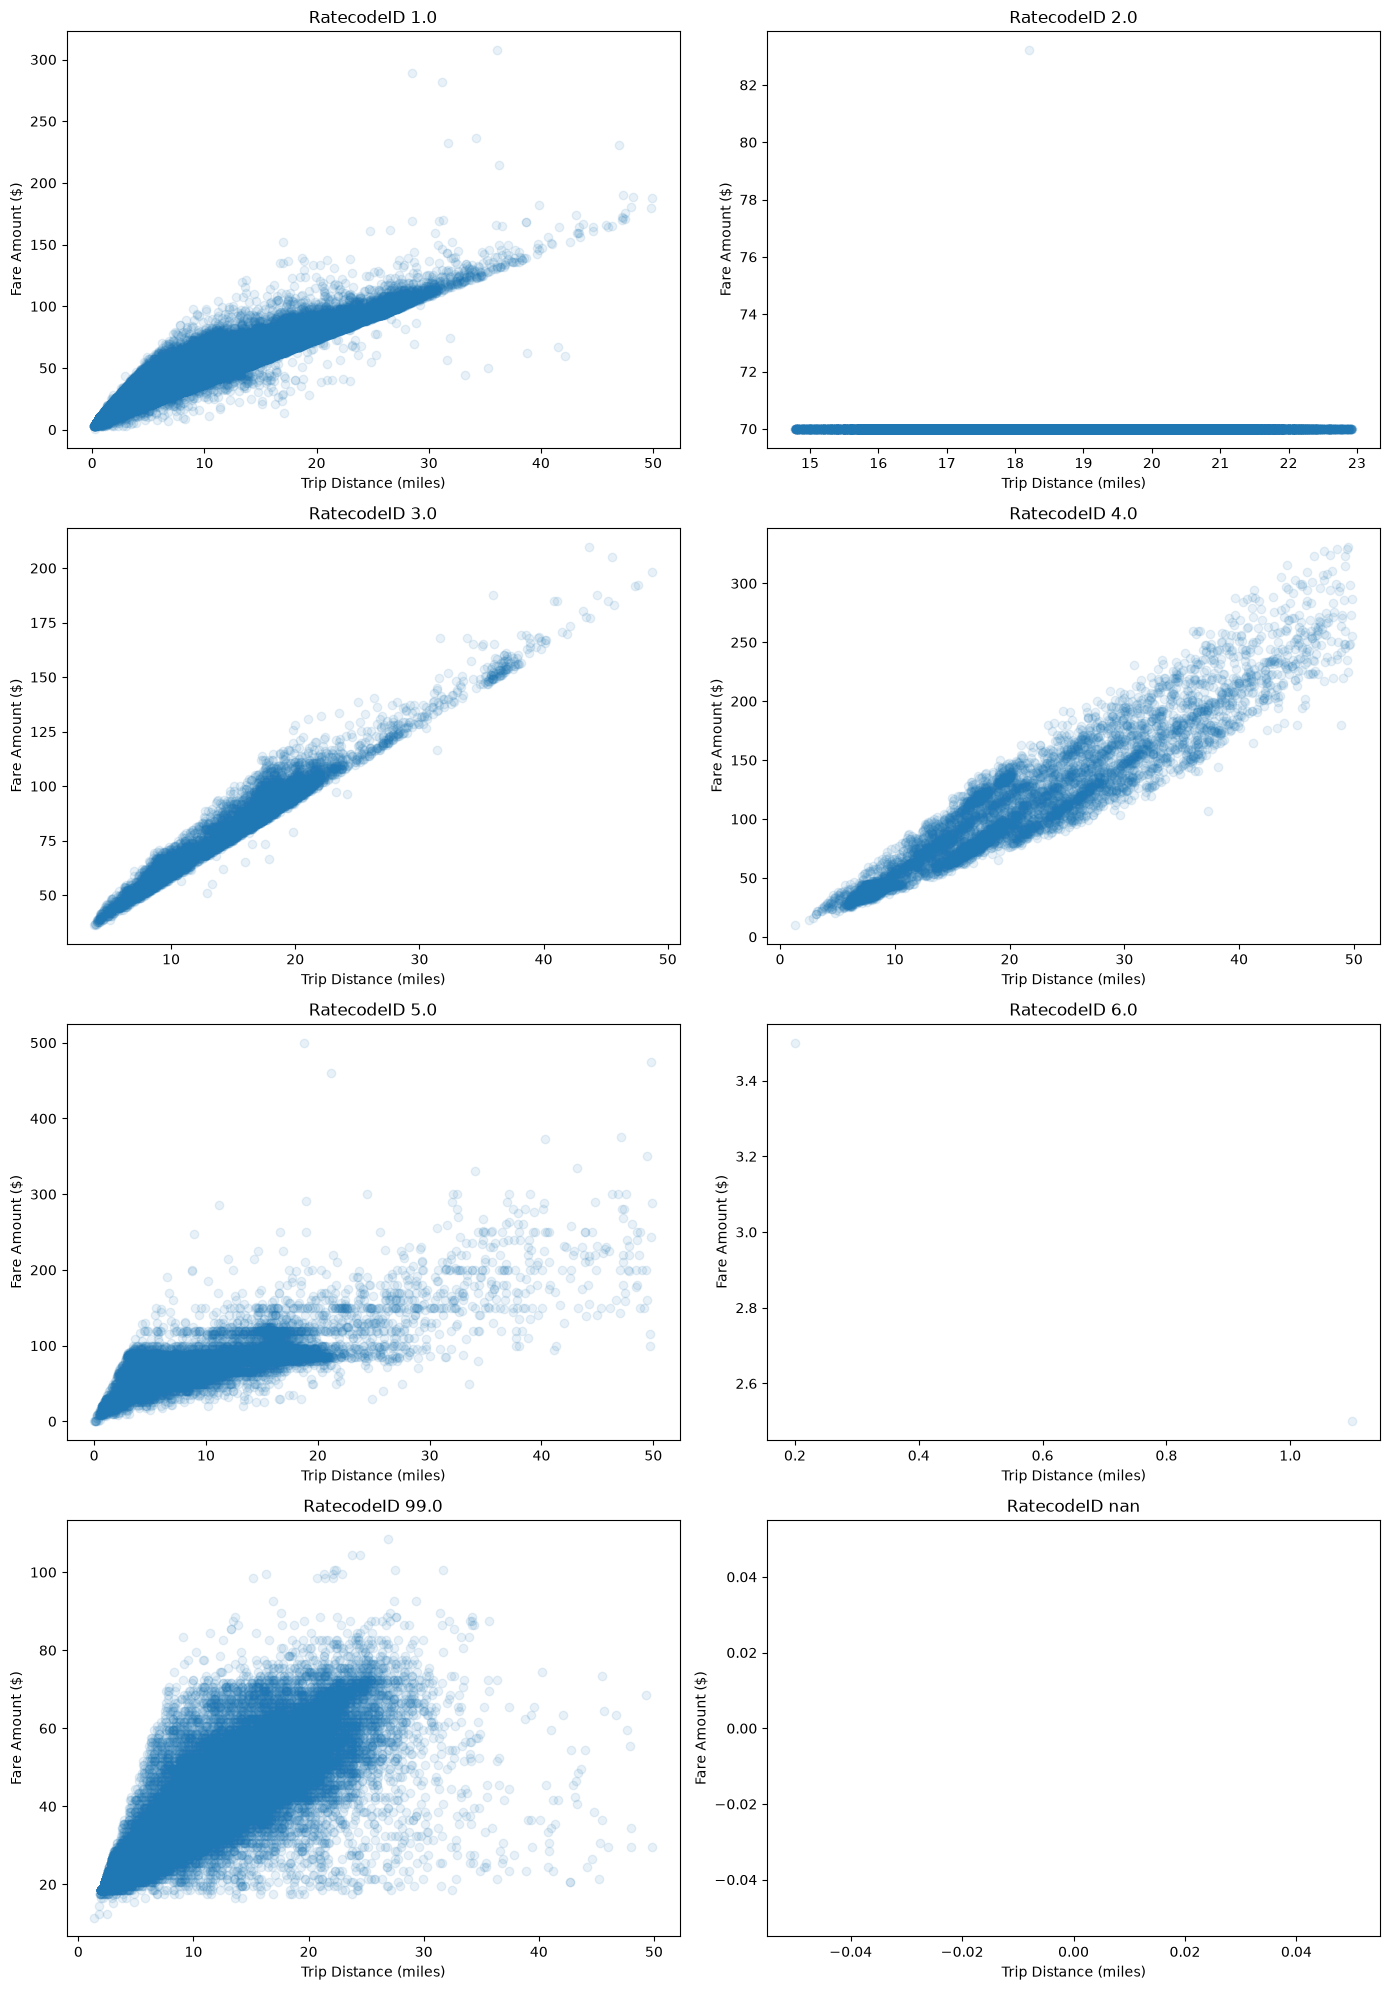

In [97]:
rate_codes = sorted(clean_df['RatecodeID'].unique())

n = len(rate_codes)
rows = (n + 1) // 2

fig, axes = plt.subplots(
    nrows=rows,
    ncols=2,
    figsize=(14, 5 * rows)
)

axes = axes.flatten()

for ax, rate_code in zip(axes, rate_codes):

    data = clean_df[clean_df['RatecodeID'] == rate_code]

    ax.scatter(
        data['trip_distance'],
        data['fare_amount'],
        alpha=0.1
    )

    ax.set_title(f'RatecodeID {rate_code}')
    ax.set_xlabel('Trip Distance (miles)')
    ax.set_ylabel('Fare Amount ($)')

# Hide unused subplot if number of rate codes is odd
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

````
RatecodeID 6 has only 2 records, so we don't need to worry about it.

RatecodeID 2 looks unusual because the fare amount is almost completely flat around $70 even though the trip distance changes.
We should investigate this rate code separately before deciding whether these values are valid or need to be removed.

In [98]:
clean_df[clean_df['RatecodeID'] == 2][
    ['RatecodeID', 'fare_amount', 'trip_distance', 'trip_duration',
     'total_amount', 'payment_type']
].sort_values('fare_amount').describe([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95,0.97,0.99])

,fare_amount,trip_distance,trip_duration,total_amount
count,71547.000000,71547.000000,71547.000000,71547.000000
mean,70.000185,18.166616,47.213776,94.942759
std,0.049386,1.403019,13.057645,8.096095
min,70.000000,14.780000,18.850000,71.500000
1%,70.000000,15.590000,25.683333,75.750000
5%,70.000000,16.240000,29.366667,81.500000
10%,70.000000,16.590000,31.816667,83.440000
25%,70.000000,17.170000,37.083333,89.440000
50%,70.000000,17.930000,45.166667,96.850000
75%,70.000000,18.980000,55.650000,100.400000


````
RatecodeID 2 has around 71K trips and the fare amount is almost always fixed at $70,
even though the trip distance varies between roughly 15 and 23 miles.

This explains why the fare vs distance graph looks flat for RatecodeID 2.
Since the pattern is consistent across a large number of records, it looks like a
fixed-rate pricing rule rather than bad data.

So we should keep these records and not remove them as outliers.

## Distribution of RatecodeID

Now that we have analysed the pricing behaviour of each rate code,
let's check how many trips belong to each RatecodeID.

This will help us identify rate codes with very few records that may not
be useful for further analysis.

In [100]:
clean_df['RatecodeID'].value_counts().sort_index()

RatecodeID
1.0     2078039
2.0       71547
3.0        8315
4.0        7094
5.0       12921
6.0           2
99.0      96925
Name: count, dtype: int64

````

RatecodeID 1 contains the majority of the trips, while RatecodeID 2 also has enough
records to analyse its fixed-fare behaviour.

RatecodeID 3, 4 and 5 have fewer records but still contain enough data for analysis.

RatecodeID 6 has only 2 records, so it is not useful for analysis and can be removed.

RatecodeID 99 has around 97K records, so it needs further investigation before
deciding whether these records should be kept or removed.

In [101]:
clean_df[clean_df['RatecodeID'] == 99][
    ['RatecodeID', 'fare_amount', 'trip_distance', 'trip_duration',
     'total_amount', 'payment_type']
].sort_values('fare_amount').describe([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95,0.97,0.99])

,fare_amount,trip_distance,trip_duration,total_amount
count,96925.000000,96925.000000,96925.000000,96925.000000
mean,37.122102,9.914646,54.555761,39.039832
std,11.744847,5.253264,26.702397,13.116793
min,11.500000,1.400000,4.383333,14.000000
1%,19.500000,2.300000,15.633333,20.000000
5%,21.500000,3.000000,21.383333,22.000000
10%,22.500000,3.700000,25.416667,23.000000
25%,27.500000,5.800000,34.550000,28.000000
50%,35.500000,9.200000,49.300000,37.000000
75%,44.500000,13.100000,69.166667,47.460000


```
RatecodeID 99 contains around 97K records, so it is a significant category.

The fare and trip distance values show a reasonable range and do not show any
obvious irregularities. The fare also varies with the trip distance, unlike the
fixed-fare pattern we saw in RatecodeID 2.

So we should keep these records for now and not remove them just because the
RatecodeID is 99.

```

RatecodeID 6 contains only 2 records, so there is not enough data to analyse
this category meaningfully.

We can simply skip it and continue with the remaining rate codes.

## Distribution of Payment Type
```
Let's check how the trips are distributed across different payment types.

This will help us identify the commonly used payment methods and any categories
with very few records that may not be useful for further analysis.

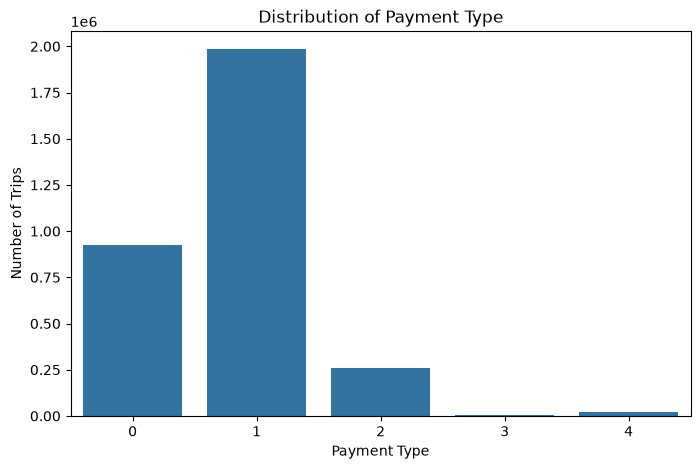

In [103]:
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x='payment_type'
)

plt.title('Distribution of Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')

plt.show()

```

Payment type 1 is the most commonly used payment method, followed by payment type 0.

Payment types 2, 3 and 4 have significantly fewer records, especially 3 and 4.
The distribution itself does not indicate any obvious data issue, so we should
investigate the smaller categories before deciding whether to remove them.

In [105]:
clean_df[clean_df['payment_type'].isin([3, 4])][
    ['payment_type', 'fare_amount', 'tip_amount',
     'total_amount', 'trip_distance', 'trip_duration']
].describe([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95,0.97,0.99])

,fare_amount,tip_amount,total_amount,trip_distance,trip_duration
count,30214.000000,30214.000000,30214.000000,30214.000000,30214.000000
mean,23.592324,0.000331,29.850321,4.548273,16.865400
std,24.192712,0.040679,26.332310,5.665758,14.088315
min,0.400000,0.000000,1.830000,0.100000,0.266667
1%,4.400000,0.000000,8.400000,0.340000,1.850000
5%,5.100000,0.000000,10.150000,0.500000,3.316667
10%,6.500000,0.000000,11.250000,0.630000,4.450000
25%,8.600000,0.000000,14.050000,1.010000,7.383333
50%,14.200000,0.000000,19.350000,1.930000,12.583333
75%,29.600000,0.000000,34.950000,6.020000,21.366667


```
Payment types 3 and 4 together contain around 30K records, so they are not
small enough to remove without further analysis.

The main observation is that the tip amount is almost always zero, while the
fare, distance and duration values look reasonable.

Therefore, these payment types do not show any obvious data-quality issue,
so we should keep them for now.

## Distribution of Passenger Count
```
Let's check the distribution of passenger_count to understand the common
number of passengers in each trip and identify any unusual or unrealistic values.

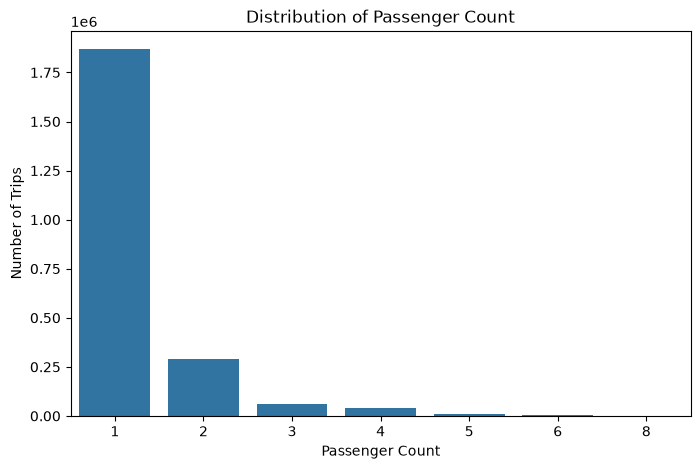

In [106]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x='passenger_count'
)

plt.title('Distribution of Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Number of Trips')

plt.show()

```
Most trips have 1 passenger, which is expected for taxi rides.

As the passenger count increases, the number of trips drops significantly. 2–4 passengers are still reasonably common, while 5–6 passengers are much less frequent.

There is also a very small number of trips with 8 passengers. Since these are rare, we should inspect them before deciding whether they are valid or unusual.

So for now, no need to drop anything just based on this distribution.


In [109]:
clean_df[clean_df['passenger_count'].isin([8])][
    ['RatecodeID', 'fare_amount', 'trip_distance', 'trip_duration',
     'total_amount', 'payment_type']
].describe([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95,0.97,0.99])

,fare_amount,trip_distance,trip_duration,total_amount
count,2.000000,2.000000,2.000000,2.000000
mean,83.500000,14.155000,47.525000,98.375000
std,0.707107,4.532554,25.090506,5.126524
min,83.000000,10.950000,29.783333,94.750000
1%,83.010000,11.014100,30.138167,94.822500
5%,83.050000,11.270500,31.557500,95.112500
10%,83.100000,11.591000,33.331667,95.475000
25%,83.250000,12.552500,38.654167,96.562500
50%,83.500000,14.155000,47.525000,98.375000
75%,83.750000,15.757500,56.395833,100.187500


```
only two entites are there 
and have reasonable trip distance and fare amount
so we can keep them

## Distribution of Store and Forward Flag

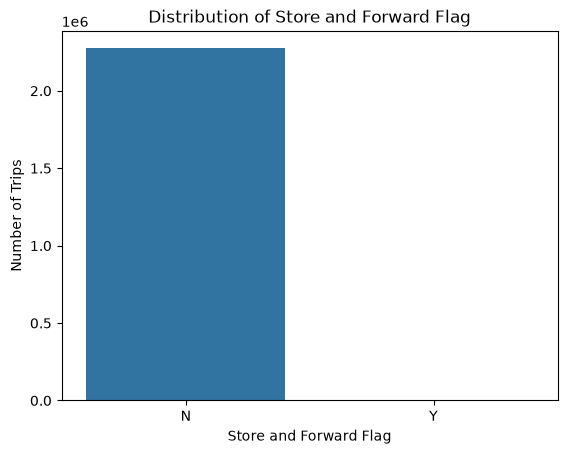

In [110]:
sns.countplot(data=clean_df, x='store_and_fwd_flag')

plt.title('Distribution of Store and Forward Flag')
plt.xlabel('Store and Forward Flag')
plt.ylabel('Number of Trips')
plt.show()

In [113]:
clean_df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    2273048
Y       1795
Name: count, dtype: int64

```
No cleaning is required here we can keep both
coz Y simply means that you store data and later sending it
so its oki to have


## Distribution of Vendor ID

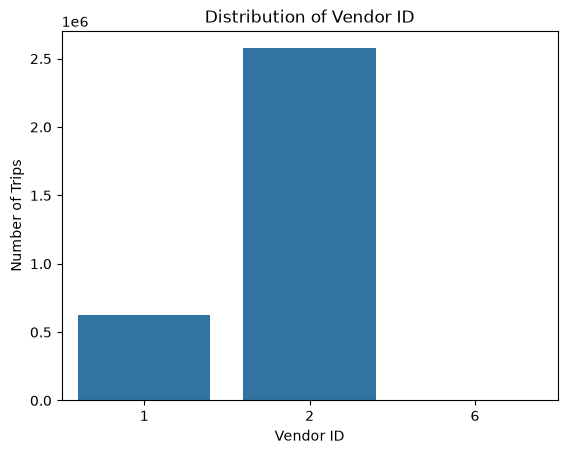

In [114]:
sns.countplot(data=clean_df, x='VendorID')

plt.title('Distribution of Vendor ID')
plt.xlabel('Vendor ID')
plt.ylabel('Number of Trips')
plt.show()

In [115]:
clean_df['VendorID'].value_counts()

VendorID
2    2574275
1     623482
6       1281
Name: count, dtype: int64

In [116]:
clean_df[clean_df['VendorID'].isin([6])][
    ['RatecodeID', 'fare_amount', 'trip_distance', 'trip_duration',
     'total_amount', 'payment_type']
].describe([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95,0.97,0.99])

,fare_amount,trip_distance,trip_duration,total_amount
count,1281.000000,1281.000000,1281.000000,1281.000000
mean,3.393755,4.096401,25.126594,21.304965
std,1.164357,2.261127,13.731281,6.852235
min,1.500000,0.270000,1.133333,0.000000
1%,1.500000,0.690000,3.680000,0.000000
5%,2.900000,1.250000,7.700000,16.000000
10%,3.000000,1.640000,10.066667,16.000000
25%,3.000000,2.510000,15.516667,16.000000
50%,3.000000,3.820000,22.416667,19.720000
75%,3.000000,5.250000,32.016667,25.000000


```
VendorID 6 has only 1,281 records, which is very small compared to the other vendors.
But these records look reasonable based on the summary — the fare, distance, duration, and total amount are not obviously impossible.
No cleaning required for VendorID. Keep all three vendors.

In [119]:
removed_percentage = (len(df) - len(clean_df)) / len(df) * 100

print(f"Rows removed: {len(df) - len(clean_df)}")
print(f"Rows remaining: {len(clean_df)}")
print(f"Percentage of rows removed: {removed_percentage:.2f}%")

Rows removed: 525851
Rows remaining: 3199038
Percentage of rows removed: 14.12%


## Final Data Cleaning Summary
```
After completing the data cleaning and removing the identified invalid and extreme
outliers, around 14.12% of the original rows were removed.

The remaining 85.88% of the data will be used for further analysis, SQL and
data pipeline development.

In [120]:
clean_df.to_parquet(
    '../data/processed/nyc_taxi_cleaned.parquet',
    index=False
)